In [3]:
import ee

# If you selected a default project during authentication:
ee.Initialize(project = 'development-hruday')

# NOTE: If it gives an error asking for a project, pass your Google Cloud project ID:
# ee.Initialize(project='your-gcp-project-id')


In [4]:
import json

geojson_path = "../raw/boundary_file/380006_boundary.geojson"

with open(geojson_path) as f:
    geojson_data = json.load(f)

# Extract polygon coordinates
coords = geojson_data["features"][0]["geometry"]["coordinates"]
geometry = ee.Geometry.Polygon(coords)

print("Boundary loaded successfully!")

Boundary loaded successfully!


In [8]:
import json
from pathlib import Path
import folium
import geopandas as gpd

# 1. Resolve path to boundary file
project_root = (
    Path().resolve().parent
    if Path().resolve().name == "notebooks"
    else Path().resolve()
)
boundary_file = (
    project_root / "raw" / "boundary_file" / "380006_boundary.geojson"
)

# 2. Read boundary with GeoPandas
gdf_boundary = gpd.read_file(boundary_file)

# 3. Extract all 213 coordinate vertices as Point features
coords = gdf_boundary.geometry.iloc[0].exterior.coords
df_points = gpd.GeoDataFrame(
    [
        {"point_id": i, "lon": pt[0], "lat": pt[1]}
        for i, pt in enumerate(coords)
    ],
    geometry=gpd.points_from_xy([c[0] for c in coords], [c[1] for c in coords]),
    crs="EPSG:4326",
)

# 4. Create an interactive map centered on the pincode
centroid = gdf_boundary.geometry.iloc[0].centroid
m = folium.Map(
    location=[centroid.y, centroid.x], zoom_start=15, tiles="CartoDB positron"
)

# Add the boundary polygon
folium.GeoJson(
    gdf_boundary,
    name="Boundary (380006)",
    style_function=lambda x: {
        "fillColor": "#3388ff",
        "color": "#0022aa",
        "weight": 2.5,
        "fillOpacity": 0.25,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["Pincode", "Office_Name"], aliases=["Pincode:", "Office:"]
    ),
).add_to(m)

# Add the 213 lat/lon coordinate markers
for _, row in df_points.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color="#ff3333",
        fill=True,
        fill_color="#ff3333",
        fill_opacity=0.9,
        popup=f"Point {row['point_id']}<br>Lat: {row['lat']:.5f}<br>Lon: {row['lon']:.5f}",
    ).add_to(m)

folium.LayerControl().add_to(m)

# Display map in notebook
m


c:\dev\case-study\.venv\Lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


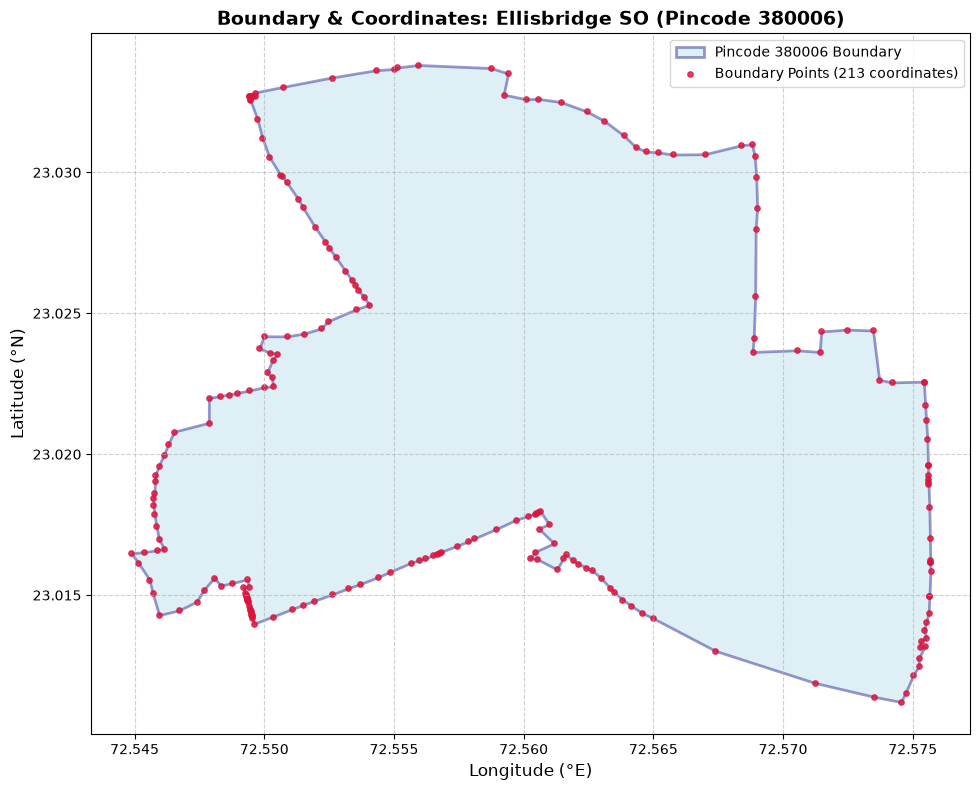

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot boundary polygon
gdf_boundary.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="navy",
    linewidth=2,
    alpha=0.4,
    label="Pincode 380006 Boundary",
)

# Plot all 213 coordinate points
df_points.plot(
    ax=ax,
    color="crimson",
    markersize=15,
    alpha=0.8,
    label=f"Boundary Points ({len(df_points)} coordinates)",
)

# Styling
pincode = gdf_boundary["Pincode"].iloc[0]
office = gdf_boundary["Office_Name"].iloc[0]
ax.set_title(
    f"Boundary & Coordinates: {office} (Pincode {pincode})",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Longitude (°E)", fontsize=12)
ax.set_ylabel("Latitude (°N)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


In [11]:
from pathlib import Path
import folium
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, box

# 1. Load boundary file
project_root = (
    Path().resolve().parent
    if Path().resolve().name == "notebooks"
    else Path().resolve()
)
boundary_file = (
    project_root / "raw" / "boundary_file" / "380006_boundary.geojson"
)
gdf_boundary = gpd.read_file(boundary_file)
bounds = gdf_boundary.total_bounds  # [minx, miny, maxx, maxy]

# 2. Build ERA5-Land 0.1° regular grid over boundary area
lons = np.arange(
    np.floor((bounds[0] - 0.05) * 10) / 10 + 0.05,
    np.ceil((bounds[2] + 0.05) * 10) / 10 + 0.05,
    0.1,
)
lats = np.arange(
    np.floor((bounds[1] - 0.05) * 10) / 10 + 0.05,
    np.ceil((bounds[3] + 0.05) * 10) / 10 + 0.05,
    0.1,
)

grid_boxes = []
grid_points = []
for lat in np.round(lats, 2):
    for lon in np.round(lons, 2):
        pixel_poly = box(lon - 0.05, lat - 0.05, lon + 0.05, lat + 0.05)

        # Check if the ERA5 grid cell touches/intersects your boundary
        if gdf_boundary.intersects(pixel_poly).any():
            grid_id = f"ERA5_{lat}_{lon}"
            grid_boxes.append(
                {
                    "grid_id": grid_id,
                    "latitude": lat,
                    "longitude": lon,
                    "geometry": pixel_poly,
                }
            )
            grid_points.append(
                {
                    "grid_id": grid_id,
                    "latitude": lat,
                    "longitude": lon,
                    "geometry": Point(lon, lat),
                }
            )

gdf_grid_boxes = gpd.GeoDataFrame(grid_boxes, crs="EPSG:4326")
gdf_grid_points = gpd.GeoDataFrame(grid_points, crs="EPSG:4326")

print(
    f"Found {len(gdf_grid_points)} ERA5-Land grid points covering this boundary:"
)
display(
    gdf_grid_points[
        ["grid_id", "latitude", "longitude"]
    ].reset_index(drop=True)
)

# 3. Interactive Map (using OpenStreetMap)
centroid = gdf_boundary.geometry.iloc[0].centroid
m = folium.Map(
    location=[centroid.y, centroid.x], zoom_start=13, tiles="OpenStreetMap"
)

# Add ERA5 grid pixel boxes (Orange dashed boxes)
folium.GeoJson(
    gdf_grid_boxes,
    name="ERA5 Grid Cells (~11km)",
    style_function=lambda x: {
        "fillColor": "#ff9900",
        "color": "#e65100",
        "weight": 2,
        "dashArray": "5, 5",
        "fillOpacity": 0.12,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["grid_id", "latitude", "longitude"]
    ),
).add_to(m)

# Add Boundary Polygon (Blue)
folium.GeoJson(
    gdf_boundary,
    name="Pincode Boundary",
    style_function=lambda x: {
        "fillColor": "#2979ff",
        "color": "#0043ce",
        "weight": 2.5,
        "fillOpacity": 0.35,
    },
    tooltip=folium.GeoJsonTooltip(fields=["Pincode", "Office_Name"]),
).add_to(m)

# Add the exact ERA5 data extraction points (Red markers)
for _, pt in gdf_grid_points.iterrows():
    lat_val, lon_val = pt["latitude"], pt["longitude"]
    folium.Marker(
        location=[lat_val, lon_val],
        icon=folium.Icon(color="red", icon="info-sign"),
        popup=f"<b>{pt['grid_id']}</b><br>Lat: {lat_val}<br>Lon: {lon_val}",
    ).add_to(m)

folium.LayerControl().add_to(m)
m


Found 1 ERA5-Land grid points covering this boundary:


,grid_id,latitude,longitude
0,ERA5_23.05_72.55,23.05,72.55


In [12]:
import json
from pathlib import Path
import ee
import folium
import geopandas as gpd
import pandas as pd

# 1. Initialize Earth Engine (if not already done)
# ee.Initialize(project='development-hruday')

# 2. Load your local boundary file
project_root = (
    Path().resolve().parent
    if Path().resolve().name == "notebooks"
    else Path().resolve()
)
boundary_file = (
    project_root / "raw" / "boundary_file" / "380006_boundary.geojson"
)
gdf_boundary = gpd.read_file(boundary_file)

with open(boundary_file) as f:
    geojson_data = json.load(f)
coords = geojson_data["features"][0]["geometry"]["coordinates"]
ee_geom = ee.Geometry.Polygon(coords)

# Buffer boundary by 6km to catch all overlapping ~11km ERA5-Land grid cells
ee_geom_buffered = ee_geom.buffer(6000)

# 3. Pull an actual ERA5-Land image from GEE
# Note: ERA5-Land only has values over land; ocean/water pixels are masked
era5_land_sample = (
    ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
    .select("temperature_2m")
    .first()
)

# Extract the exact native ERA5-Land pixel coordinates having data
native_pixels = era5_land_sample.sample(
    region=ee_geom_buffered, scale=11132, geometries=True
).getInfo()

# Build DataFrame of native ERA5-Land data points
points_data = []
for i, feat in enumerate(native_pixels["features"]):
    lon, lat = feat["geometry"]["coordinates"]
    points_data.append(
        {
            "grid_id": f"ERA5_LAND_{i+1}",
            "latitude": lat,
            "longitude": lon,
            "sample_temp_k": feat["properties"]["temperature_2m"],
            "sample_temp_c": feat["properties"]["temperature_2m"] - 273.15,
        }
    )

df_era5_points = pd.DataFrame(points_data)
print(f" Found {len(df_era5_points)} ERA5-Land data points covering your area:")
display(df_era5_points)

# 4. Interactive Map with real ERA5-Land Raster Layer from GEE
centroid = gdf_boundary.geometry.iloc[0].centroid
m = folium.Map(
    location=[centroid.y, centroid.x], zoom_start=11, tiles="OpenStreetMap"
)

# A. Add live ERA5-Land temperature raster layer directly from GEE
vis_params = {"min": 280, "max": 310, "palette": ["blue", "yellow", "red"]}
map_id = era5_land_sample.getMapId(vis_params)
folium.raster_layers.TileLayer(
    tiles=map_id["tile_fetcher"].url_format,
    attr="Google Earth Engine - ERA5-Land",
    name="ERA5-Land Temperature Raster",
    overlay=True,
    control=True,
    opacity=0.55,
).add_to(m)

# B. Add your Pincode Boundary Polygon
folium.GeoJson(
    gdf_boundary,
    name="Pincode Boundary (380006)",
    style_function=lambda x: {
        "fillColor": "#00e5ff",
        "color": "#000000",
        "weight": 2.5,
        "fillOpacity": 0.35,
    },
    tooltip=folium.GeoJsonTooltip(fields=["Pincode", "Office_Name"]),
).add_to(m)

# C. Add the native ERA5-Land data points
for _, pt in df_era5_points.iterrows():
    lat_val, lon_val = pt["latitude"], pt["longitude"]
    folium.Marker(
        location=[lat_val, lon_val],
        icon=folium.Icon(color="red", icon="cloud"),
        popup=f"<b>{pt['grid_id']}</b><br>Lat: {lat_val:.5f}<br>Lon: {lon_val:.5f}<br>Sample Temp: {pt['sample_temp_c']:.1f}°C",
    ).add_to(m)

folium.LayerControl().add_to(m)
m


 Found 2 ERA5-Land data points covering your area:


,grid_id,latitude,longitude,sample_temp_k,sample_temp_c
0,ERA5_LAND_1,22.999693,72.501155,292.479354,19.329354
1,ERA5_LAND_2,22.999693,72.601156,292.501163,19.351163


In [15]:
import ee
import json
import pandas as pd

# ee.Authenticate() # Uncomment and run once to authenticate your Google account
ee.Initialize(project = 'development-hruday')

# 1. Load your local GeoJSON file
with open('../raw/boundary_file/380006_boundary.geojson', 'r') as f:
    geojson_dict = json.load(f)

# Extract coordinates and create a GEE geometry (Assuming a single Polygon feature)
coords = geojson_dict['features'][0]['geometry']['coordinates']
roi = ee.Geometry.Polygon(coords)

# 2. Define Dataset and Timeframe
era5_land = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR") \
    .filterBounds(roi) \
    .filterDate('2005-01-01', '2024-12-31')

# 3. Define the exact GEE band names for the requested variables
variables = {
    'solar_radiation': 'surface_solar_radiation_downwards_sum',
    'temperature': 'temperature_2m',
    'precipitation': 'total_precipitation_sum'
}

# 4. Extract data one by one per grid cell
scale_meters = 11132  # Native resolution of ERA5-Land

for var_name, band_name in variables.items():
    print(f"Extracting {var_name} ({band_name}) per grid cell...")
    
    # Select the single band
    collection_single_band = era5_land.select(band_name)
    
    # getRegion extracts values for all pixels intersecting the ROI
    # It returns a list of lists: [id, longitude, latitude, time, variable_value]
    region_data = collection_single_band.getRegion(roi, scale_meters).getInfo()
    
    # Convert to Pandas DataFrame
    headers = region_data[0]
    data_rows = region_data[1:]
    df = pd.DataFrame(data_rows, columns=headers)
    
    # Clean and format the DataFrame
    if not df.empty:
        # Convert GEE timestamp (milliseconds) to readable Datetime
        df['datetime'] = pd.to_datetime(df['time'], unit='ms')
        
        # Drop redundant columns
        df = df.drop(columns=['time', 'id'])
        
        # Save to local CSV
        output_filename = f"ERA5_{var_name}_2005_2024_grid_cells.csv"
        df.to_csv(output_filename, index=False)
        print(f"Saved {output_filename}. Found {df[['longitude', 'latitude']].drop_duplicates().shape[0]} unique grid cells.")
    else:
        print(f"No data found for {var_name}.")

Extracting solar_radiation (surface_solar_radiation_downwards_sum) per grid cell...


EEException: User memory limit exceeded.